In [1]:
# %matplotlib inline
%time from hikyuu.interactive import *

Initialize hikyuu_2.8.2_202609250345_RELEASE_macosx_arm64 ...
2026-09-25 13:37:45.537 [HKU-I] - current python version: 3.13.12 (main.cpp:77)


2026-09-25 13:37:47,022 [INFO] runing in interactive session [<module>] (/Users/fasiondog/workspace/hikyuu/hikyuu/__init__.py:149) [hikyuu::hku_info]
2026-09-25 13:37:47,022 [INFO] running in jupyter [<module>] (/Users/fasiondog/workspace/hikyuu/hikyuu/__init__.py:156) [hikyuu::hku_info]


2026-09-25 13:37:47.027 [HKU-I] - 插件路径: /Users/fasiondog/workspace/hku_plugin/hikyuu_plugin (StockManager.cpp:124)
2026-09-25 13:37:47.067 [HKU-I] - Using CLICKHOUSE BaseInfoDriver (BaseInfoDriver.cpp:56)
2026-09-25 13:37:47.107 [HKU-I] - 加载市场信息…… (StockManager.cpp:1050)
2026-09-25 13:37:47.121 [HKU-I] - 加载证券类型信息…… (StockManager.cpp:1067)
2026-09-25 13:37:47.132 [HKU-I] - 加载证券信息…… (StockManager.cpp:948)
2026-09-25 13:37:47.280 [HKU-I] - 加载权息数据…… (StockManager.cpp:1170)
2026-09-25 13:37:47.519 [HKU-I] - 加载板块信息…… (StockManager.cpp:214)
2026-09-25 13:37:47.637 [HKU-I] - 加载K线数据…… (StockManager.cpp:221)
2026-09-25 13:37:47.638 [HKU-I] - 预加载 day K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:395)
2026-09-25 13:37:47.638 [HKU-I] - 0.56 秒数据加载完毕. (StockManager.cpp:231)
CPU times: user 2.35 s, sys: 206 ms, total: 2.55 s
Wall time: 3.35 s


#  1 绘制指标

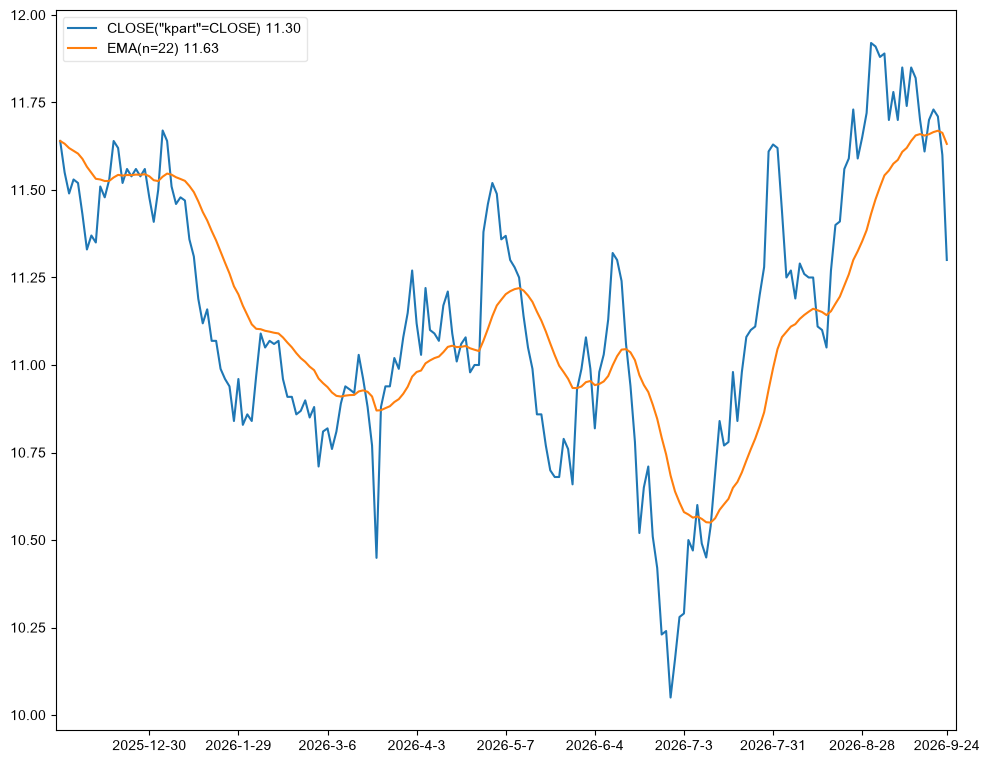

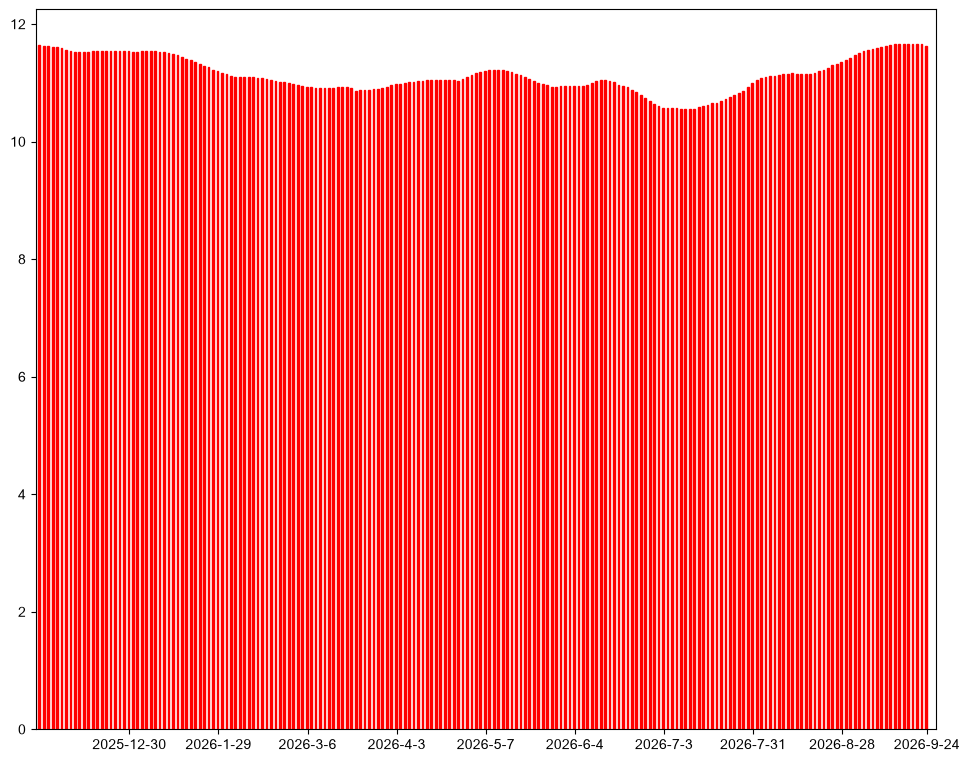

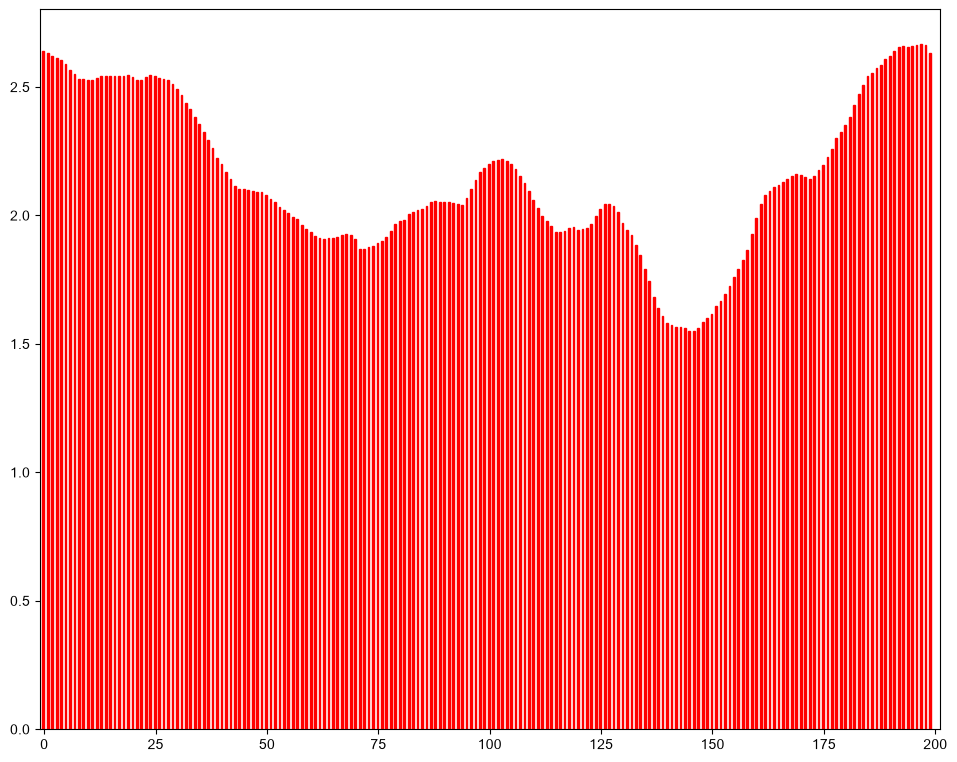

In [2]:
s = sm['sz000001']
k = s.get_kdata(Query(-200))


# Extract the close price indicator of the K-line; generally the calculation parameters of an indicator can only be of the indicator type, so the K-line data must first be converted to the indicator type
c = CLOSE(k)

# Calculate the EMA indicator of the close price
a = EMA(c)

# Draw the indicator
c.plot(legend_on=True)
a.plot(new=False, legend_on=True)

# Draw the bar chart
a.bar()

# Adjust the bar chart to make it more beautiful
PRICELIST([x-9 for x in a]).bar()

# 2 指标（Indicator）

在 Hikyuu 中，Indicator 的实例是用于计算的主要数据结构，一般 ind（如无说明，ind代表Indicator的实例）计算的参数为另一个ind，如EMA(x),x应是一个Indicator的实例。可以简单的理解为类似 numpy.array。

## 2.1 特殊的Indicator

其中存在一类特殊的Indicator，用于将K线数据或普通数组转换为ind，才能供其他ind进行计算，如 KDATA 将 KData 转化为一个ind。其他包括: OPEN,HIGH,LOW,CLOSE,AMO(成交金额),VOL(成交量),KDATA_PART。

In [3]:
print("k is a instance of KData:\n", k)
print("--------------------------\n")

kind = KDATA(k)
print("kind is a instance of Indicator:\n", kind)

k is a instance of KData:
 KData{
  size : 200
  stock: Stock(SZ, 000001, 平安银行, A股, 1, 1991-04-03 00:00:00, +infinity),
  query: KQuery(-200, 9223372036854775807, INDEX, DAY, NO_RECOVER)
  first: KRecord(Datetime(20251202000000), 11.6800, 11.7300, 11.5900, 11.6400, 89472.1024, 768059.0080)
  last: KRecord(Datetime(20260924000000), 11.3500, 11.4700, 11.2900, 11.3000, 118673.6896, 1043818.0000)
}
--------------------------

kind is a instance of Indicator:
 Indicator{
  name: KDATA
  size: 200
  discard: 0
  stock: SZ000001
  result sets: 6
  params: params[kpart(string): KDATA, ]
  is python object: False
  formula: KDATA
  first: 2025-12-02 00:00:00
  last: 2026-09-24 00:00:00
  values0: [11.68, 11.64, 11.55, ..., 11.7, 11.68, 11.35]
  values1: [11.73, 11.7, 11.58, ..., 11.75, 11.71, 11.47]
  values2: [11.59, 11.54, 11.46, ..., 11.62, 11.55, 11.29]
  values3: [11.64, 11.55, 11.49, ..., 11.71, 11.6, 11.3]
  values4: [89472.1, 109917, 101918, ..., 88770.3, 105202, 118674]
  values5: [768

In [4]:
# Get the number of the result sets of ind, e.g. MACD usually returns 3 result sets
r = kind.get_result_num()
print("result_num: ", r)

# Get the first result set
x = kind.get_result(0)
print(x)

result_num:  6
Indicator{
  name: KDATA
  size: 200
  discard: 0
  stock: 
  result sets: 1
  params: params[]
  is python object: False
  formula: KDATA
  values0: [11.68, 11.64, 11.55, ..., 11.7, 11.68, 11.35]
}


In [5]:
# The following are equivalent
c1 = CLOSE(k)
c2 = KDATA_PART(k, 'CLOSE')

另外一个常用的特殊指标 PRICELIST将 Python 中的类 list 对象包装成ind。

In [6]:
x = PRICELIST([i for i in range(100)])
print(len(x), x)

100 Indicator{
  name: PRICELIST
  size: 100
  discard: 0
  stock: 
  result sets: 1
  params: params[data(PriceList): 100, discard(int64): 0, ]
  is python object: False
  formula: PRICELIST
  values0: [0, 1, 2, ..., 97, 98, 99]
}


## 2.2 Indicator的特性与参数

每一个指标函数，如EMA、HHV，调用后生成一个ind对象，该对象本身可以再次调用生成新的ind。无论指标函数还是 ind 对象调用生成 ind，都是立刻进行计算。

In [7]:
e1 = EMA(CLOSE(k), n=5)
e2 = e1(CLOSE(k))
e3 = e2
print(e1 == e2)

Indicator{
  name: EQ
  size: 200
  discard: 0
  stock: 
  result sets: 1
  params: params[]
  is python object: False
  formula: EMA(CLOSE) == EMA(CLOSE)
  values0: [1, 1, 1, ..., 1, 1, 1]
}


除在指标函数中指定参数外，可以通过 getParam、setParam 方法来获取和修改 ind 对象的参数。修改参数后，ind 本身并不会发生变化，需要调用生成新的 ind，新的 ind 才是使用新参数计算的结果。

Indicator{
  name: EMA
  size: 200
  discard: 0
  stock: SZ000001
  result sets: 1
  params: params[n(int64): 22, ]
  is python object: False
  formula: EMA(CLOSE)
  first: 2025-12-02 00:00:00
  last: 2026-09-24 00:00:00
  values0: [11.64, 11.6322, 11.6198, ..., 11.6693, 11.6633, 11.6317]
}
22


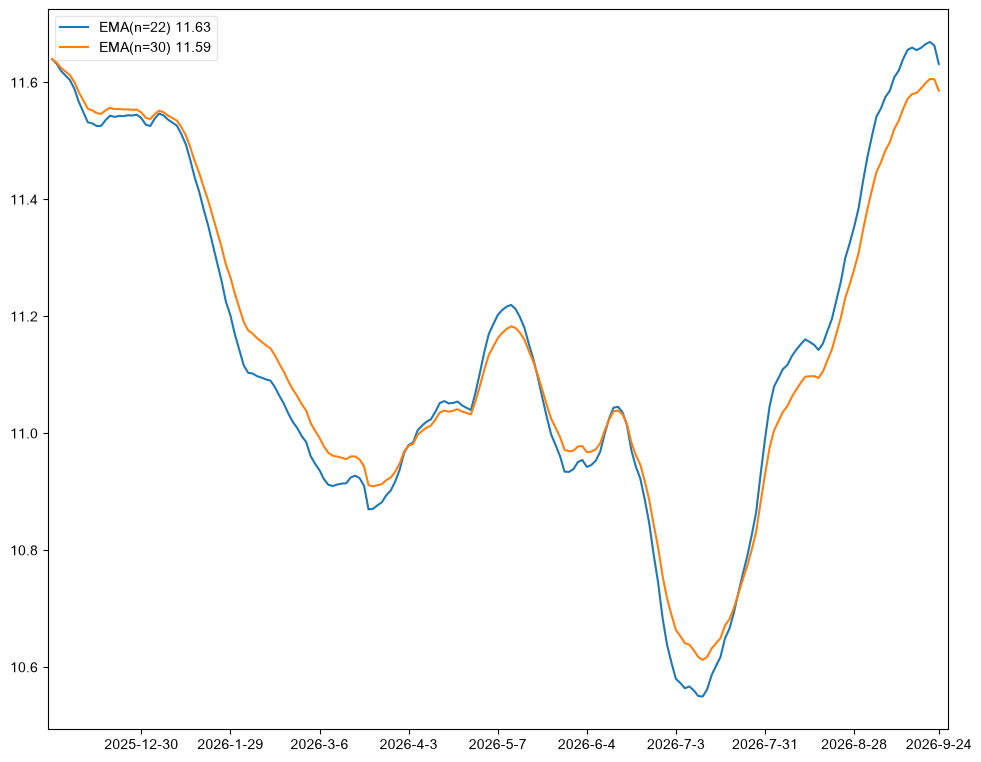

In [8]:
e = EMA(c)
print(e)
print(e.get_param('n'))
e.plot(legend_on=True)

e.set_param('n', 30)
e = e(c)
e.plot(new=False, legend_on=True)

查看 ind 参数。ind 参数支持：

- i : int
- s : str
- b : bool
- d : float

In [9]:
# The EMA indicator has a parameter "n"; the type "i" means an integer
print(EMA())

Indicator{
  name: EMA
  size: 0
  discard: 0
  stock: 
  result sets: 1
  params: params[n(int64): 22, ]
  is python object: False
  formula: EMA
  values0: []
}


## 2.3 TA-Lib包装指标

在交互工具里对TA-Lib进行了包装，命名方式统一为 TA_FUNC名称。其中，ta-lib指标的lookback属性，用discard属性代替。

Indicator{
  name: TA_SMA
  size: 200
  discard: 29
  stock: SZ000001
  result sets: 1
  params: params[n(int64): 30, ]
  is python object: False
  formula: TA_SMA(CLOSE)
  first: 2025-12-02 00:00:00
  last: 2026-09-24 00:00:00
  values0: [nan, nan, nan, ..., 11.6057, 11.6173, 11.619]
}
29


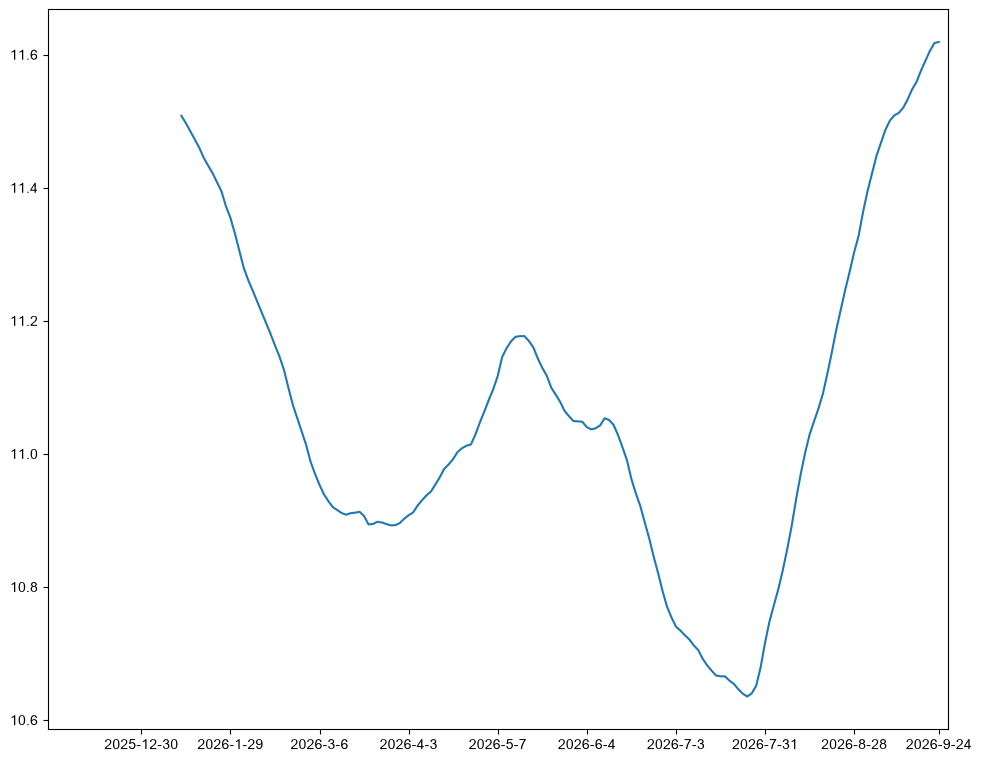

In [10]:
x = TA_SMA(CLOSE(k))
print(x)
x.plot()

print(x.discard)

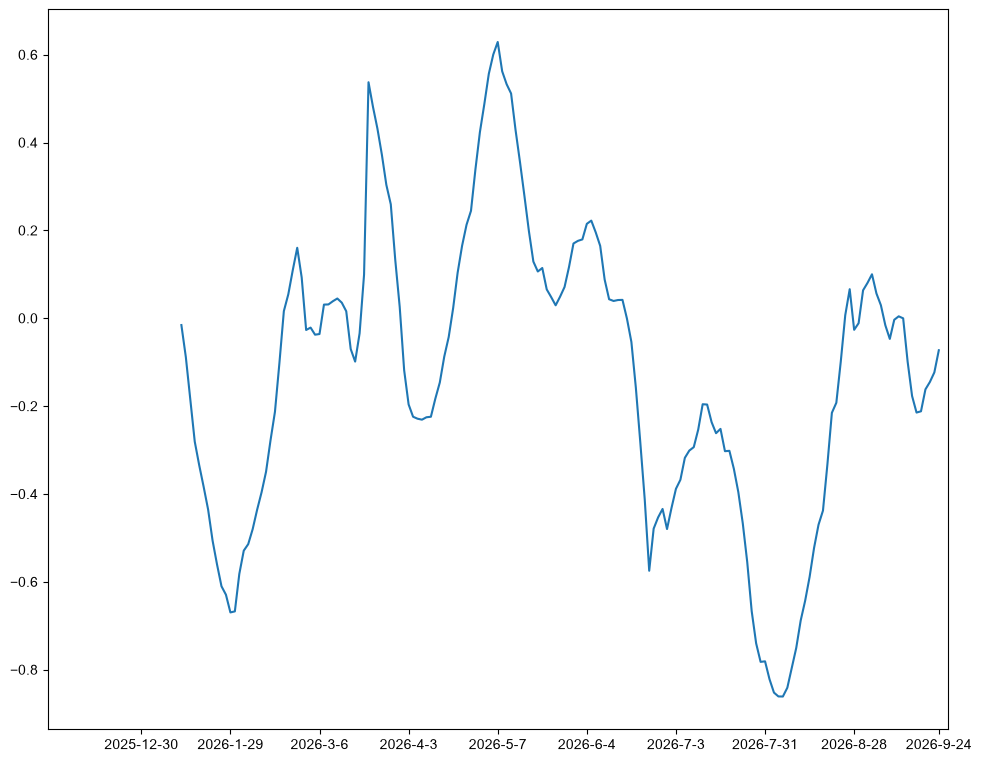

In [11]:
query = Query(-200)
k1 = sm['sh000001'].get_kdata(query)
k2 = sm['sz000001'].get_kdata(query)

cr = TA_CORREL(CLOSE(k1), CLOSE(k2))
cr.plot()

## 2.4 动态指标参数

在通道信等证券行情软件中，其技术指标中的窗口参数通常支持整数，也支持使用指标，如：

```
T1:=HHVBARS(H,120); {120内的最高点距今天的天数}
L120:=LLV(L,T1+1); {120内的最高点至今，这个区间的最低点}
```

***自 1.2.3 版本后，Hikyuu 也开始支持使用指标作为窗口参数***

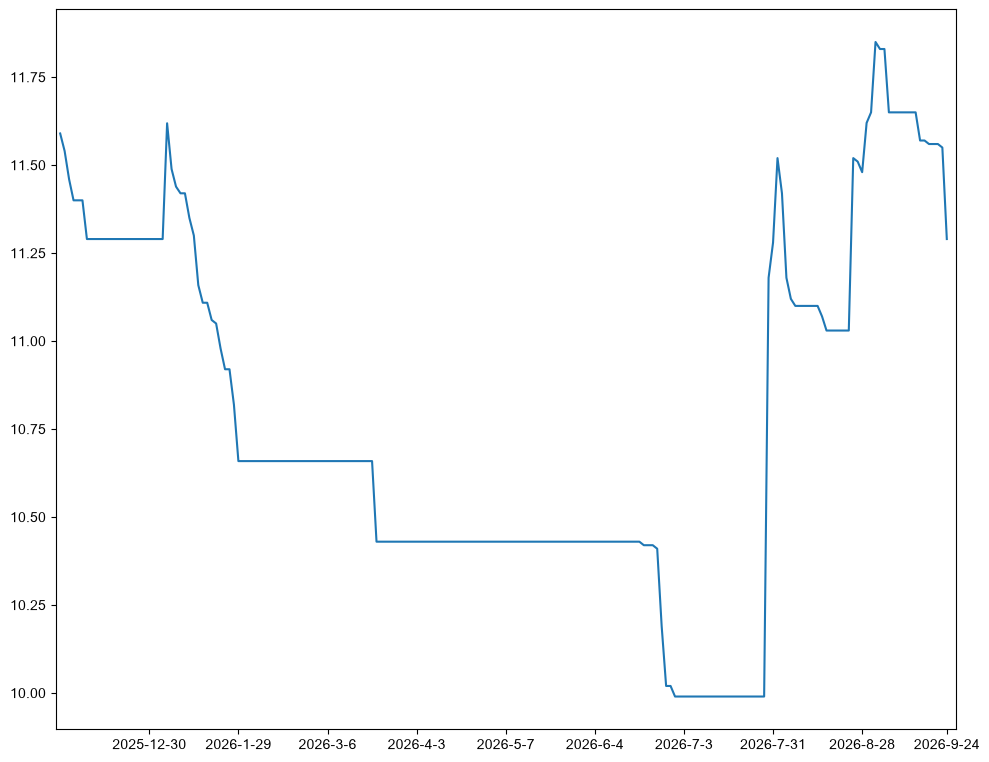

In [12]:
h = HIGH(k)
l = LOW(k)
T1 = HHVBARS(h, 120)
L120 = LLV(l, T1+1)
L120.plot()

**注意事项**

由于无法区分 Indicator(ind) 形式时，ind 究竟是指标参数还是待计算的输出数据，此时如果希望 ind 作为参数，需要通过 IndParam 进行显示指定，如：EMA(IndParam(ind))。

最佳的方式，则是通过指定参数名，来明确说明使用的是参数：

```
x = EMA(c)  # 以收盘价作为计算的输入
y = EMA(IndParam(c)) # 以收盘价作为 n 参数
z = EMA(n=c) # 以收盘价作为参数 n
```

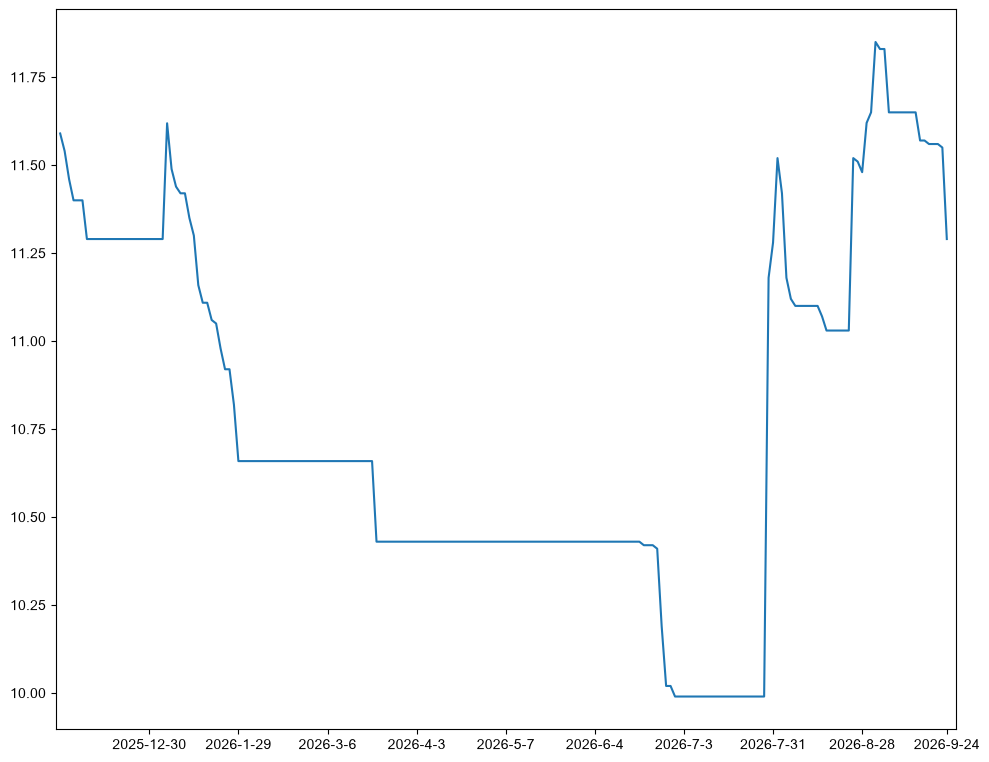

In [13]:
# Or calculate in the prototype way by specifying the context
T1 = HHVBARS(H, 120)
L120 = LLV(L, T1+1)
L120.set_context(k)
L120.plot()